Hi everyone, this is Ahmed, your mentor and trainer. It was great having you in this session! If you'd like to stay connected or continue the conversation, feel free to connect with me on LinkedIn: https://www.linkedin.com/in/ahmed-al-imaad

Looking forward to connecting with you. Wishing you all the best in your learning journey!


In [ ]:
!pip install -U langgraph langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.0/133.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 27.0 MB/s eta 0:00:00
  Attempting uninstall: langchain-protocol
    Found existing installation: langchain-protocol 0.0.16
    Uninstalling langchain-protocol-0.0.16:
      Successfully uninstalled langchain-protocol-0.0.16
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.3
    Uninstalling langchain-core-1.4.3:
      Successfully uninstalled langchain-core-1.4.3
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.4
    Uninstalling langgraph-1.2.4:
      Successfully uninstalled langgraph-1.2.4
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.6
    Uninstalling langchain-1.3.6:
      Suc

In [ ]:
from typing import Annotated

from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI

In [ ]:

from typing import TypedDict

class AgentState(TypedDict):
    user_input: str
    agent_a_output: str
    agent_b_output: str
    agent_c_output: str

In [ ]:
def agent_a(state: AgentState):
    return {
        "agent_a_output": f"Agent A received: {state['user_input']}"
    }

In [ ]:
def agent_b(state: AgentState):
    return {
        "agent_b_output": (
            f"Agent B processed -> {state['agent_a_output']}"
        )
    }

In [ ]:
def agent_c(state: AgentState):
    return {
        "agent_c_output": (
            f"Final result -> {state['agent_b_output']}"
        )
    }

In [ ]:
builder = StateGraph(AgentState)

builder.add_node("agent_a", agent_a)
builder.add_node("agent_b", agent_b)
builder.add_node("agent_c", agent_c)

builder.add_edge(START, "agent_a")
builder.add_edge("agent_a", "agent_b")
builder.add_edge("agent_b", "agent_c")
builder.add_edge("agent_c", END)

graph = builder.compile()

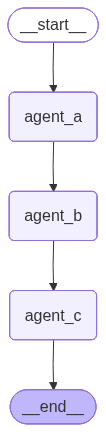

In [ ]:
from IPython.display import Image, display

# Display the graph as a Mermaid diagram
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
result = graph.invoke(
    {
        "user_input": "Hello LangGraph!",
        "agent_a_output": "",
        "agent_b_output": "",
        "agent_c_output": "",
    }
)

print(result)

{'user_input': 'Hello LangGraph!', 'agent_a_output': 'Agent A received: Hello LangGraph!', 'agent_b_output': 'Agent B processed -> Agent A received: Hello LangGraph!', 'agent_c_output': 'Final result -> Agent B processed -> Agent A received: Hello LangGraph!'}


### **Conditonl Edge**

In [ ]:
import re
from typing import TypedDict

from langgraph.graph import StateGraph, START, END

In [ ]:
class AgentState(TypedDict):
    user_input: str
    intent: str
    response: str

In [ ]:
def input_agent(state: AgentState):
    print("Input Agent executed")
    return {}

In [ ]:
def intent_checker(state: AgentState):
    text = state["user_input"].lower()

    # Very simple regex for detecting math-like input
    pattern = r"\b(add|sum|multiply|subtract|divide|\d+)\b"

    if re.search(pattern, text):
        intent = "math"
    else:
        intent = "general"

    return {"intent": intent}

In [ ]:
def math_agent(state: AgentState):
    return {
        "response": "I think this is a math-related question."
    }

In [ ]:
def chat_agent(state: AgentState):
    return {
        "response": "I think this is a general conversation."
    }

In [ ]:
def summary_agent(state: AgentState):
    print("Final Response:", state["response"])
    return {}

In [ ]:
def route(state: AgentState):
    if state["intent"] == "math":
        return "math_agent"
    return "chat_agent"

In [ ]:
builder = StateGraph(AgentState)

builder.add_node("input_agent", input_agent)
builder.add_node("intent_checker", intent_checker)
builder.add_node("math_agent", math_agent)
builder.add_node("chat_agent", chat_agent)
builder.add_node("summary_agent", summary_agent)

builder.add_edge(START, "input_agent")
builder.add_edge("input_agent", "intent_checker")

builder.add_conditional_edges(
    "intent_checker",
    route,
    {
        "math_agent": "math_agent",
        "chat_agent": "chat_agent",
    },
)

builder.add_edge("math_agent", "summary_agent")
builder.add_edge("chat_agent", "summary_agent")
builder.add_edge("summary_agent", END)

graph = builder.compile()

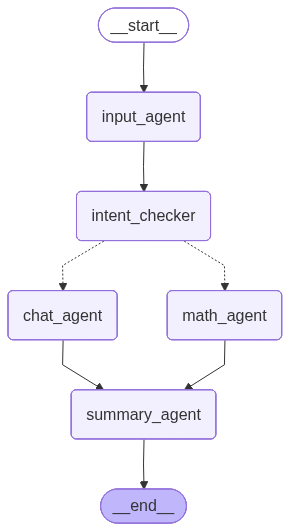

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
result = graph.invoke(
    {
        "user_input": "Can you add 15 and 27?",
        "intent": "",
        "response": "",
    }
)

print(result)

Input Agent executed
Final Response: I think this is a math-related question.
{'user_input': 'Can you add 15 and 27?', 'intent': 'math', 'response': 'I think this is a math-related question.'}


In [ ]:
result = graph.invoke(
    {
        "user_input": "Tell me a joke.",
        "intent": "",
        "response": "",
    }
)

print(result)

Input Agent executed
Final Response: I think this is a general conversation.
{'user_input': 'Tell me a joke.', 'intent': 'general', 'response': 'I think this is a general conversation.'}


### **Intent Agent (LLM) → Uses GPT-4o Mini**

In [ ]:
!pip install -U langgraph langchain-openai

In [ ]:
# # !pip install -U langgraph langchain-google-genai
# import os
# from google.colab import userdata

# os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

In [ ]:
# from langchain_google_genai import ChatGoogleGenerativeAI

# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=0
# )

In [ ]:
# !pip install -U langgraph langchain-groq
# import os
# from google.colab import userdata

# os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

# from langchain_groq import ChatGroq

# llm = ChatGroq(
#     model="llama-3.3-70b-versatile",
#     temperature=0
# )

In [ ]:
import os
from google.colab import userdata

# In Colab, create a secret named: OPENAI_API_KEY
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

In [ ]:
class AgentState(TypedDict):
    user_input: str
    intent: str
    response: str
    final_answer: str

In [ ]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=200
)

In [ ]:
def intent_agent(state: AgentState):
    prompt = f"""
Classify the user's request into exactly one label.

Possible labels:
- math
- general

Reply with ONLY the label.

User:
{state["user_input"]}
"""

    result = llm.invoke(prompt).content.strip().lower()

    if "math" in result:
        result = "math"
    else:
        result = "general"

    print("Detected intent:", result)

    return {"intent": result}

In [ ]:
def math_agent(state: AgentState):
    import re

    text = state["user_input"]

    # Extract a simple arithmetic expression
    match = re.search(r"[\d\.\+\-\*\/\(\)\s]+", text)

    if not match:
        answer = "Could not find a math expression."
    else:
        expr = match.group().strip()

        try:
            # Demo only: evaluates simple arithmetic expressions.
            answer = str(eval(expr, {"__builtins__": {}}, {}))
        except Exception:
            answer = "Unable to evaluate the expression."

    return {"response": answer}

In [ ]:
def general_agent(state: AgentState):
    answer = llm.invoke(state["user_input"]).content

    return {
        "response": answer
    }

In [ ]:
def summary_agent(state: AgentState):
    final = f"""
Intent: {state['intent']}

Answer:
{state['response']}
"""

    return {
        "final_answer": final
    }

In [ ]:
def router(state: AgentState):
    if state["intent"] == "math":
        return "math_agent"

    return "general_agent"

In [ ]:
builder = StateGraph(AgentState)

builder.add_node("intent_agent", intent_agent)
builder.add_node("math_agent", math_agent)
builder.add_node("general_agent", general_agent)
builder.add_node("summary_agent", summary_agent)

builder.add_edge(START, "intent_agent")

builder.add_conditional_edges(
    "intent_agent",
    router,
    {
        "math_agent": "math_agent",
        "general_agent": "general_agent",
    },
)

builder.add_edge("math_agent", "summary_agent")
builder.add_edge("general_agent", "summary_agent")
builder.add_edge("summary_agent", END)

graph = builder.compile()

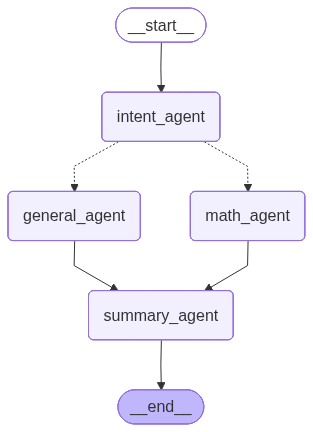

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
result = graph.invoke(
    {
        "user_input": "45 * (10 + 2)",
        "intent": "",
        "response": "",
        "final_answer": "",
    }
)

print(result["final_answer"])

Detected intent: math

Intent: math

Answer:
540



In [ ]:
result = graph.invoke(
    {
        "user_input": "Why is the sky blue?",
        "intent": "",
        "response": "",
        "final_answer": "",
    }
)

print(result["final_answer"])

Detected intent: general

Intent: general

Answer:
The sky appears blue primarily due to a phenomenon called Rayleigh scattering. When sunlight enters the Earth's atmosphere, it is made up of different colors, each with varying wavelengths. Blue light has a shorter wavelength compared to other colors like red or yellow.

As sunlight passes through the atmosphere, it collides with gas molecules and small particles. Because blue light is scattered in all directions more than other colors due to its shorter wavelength, we see a predominance of blue when we look up at the sky. 

During sunrise and sunset, the sun is lower on the horizon, and its light has to pass through a greater thickness of the atmosphere. This causes more scattering of the shorter wavelengths and allows the longer wavelengths (like red and orange) to dominate, which is why the sky can appear red or orange at those times.

